In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [15]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" 
PROCESSED_DIR = DATA_DIR / "processed"

master_df = pd.read_parquet(PROCESSED_DIR / "master_df.parquet")

# Data Exploration, Making df that help us to predict XG, And dealing with nan values (preprocessing)

In [16]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2270106 entries, 0 to 2270105
Data columns (total 16 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   match_id                int64  
 1   team                    str    
 2   type                    str    
 3   ball_x_start            float64
 4   ball_y_start            float64
 5   dist_to_goal            float64
 6   shot_angle              float64
 7   in_penalty_box          int64  
 8   ends_in_goal            int64  
 9   trajectory_angle        float64
 10  trajectory_length       float64
 11  dist_nearest_defender   float64
 12  defenders_in_3m         float64
 13  ball_speed              float64
 14  team_centroid_distance  float64
 15  open_angle_goal         float64
dtypes: float64(11), int64(3), str(2)
memory usage: 309.4 MB


In [17]:
master_df.columns

Index(['match_id', 'team', 'type', 'ball_x_start', 'ball_y_start',
       'dist_to_goal', 'shot_angle', 'in_penalty_box', 'ends_in_goal',
       'trajectory_angle', 'trajectory_length', 'dist_nearest_defender',
       'defenders_in_3m', 'ball_speed', 'team_centroid_distance',
       'open_angle_goal'],
      dtype='str')

In [18]:
master_df['type'].unique()

<ArrowStringArray>
[          'Pass',          'Carry',       'Pressure',           'Shot',
    'Goal Keeper', 'Foul Committed',       'Foul Won']
Length: 7, dtype: str

In [19]:
master_df.dtypes

match_id                    int64
team                          str
type                          str
ball_x_start              float64
ball_y_start              float64
dist_to_goal              float64
shot_angle                float64
in_penalty_box              int64
ends_in_goal                int64
trajectory_angle          float64
trajectory_length         float64
dist_nearest_defender     float64
defenders_in_3m           float64
ball_speed                float64
team_centroid_distance    float64
open_angle_goal           float64
dtype: object

In [20]:
for col in master_df.columns:
  print(col)
  print(master_df[col].nunique())

match_id
1005
team
94
type
7
ball_x_start
1209
ball_y_start
808
dist_to_goal
465904
shot_angle
534528
in_penalty_box
2
ends_in_goal
2
trajectory_angle
675114
trajectory_length
567691
dist_nearest_defender
10585
defenders_in_3m
7
ball_speed
1347768
team_centroid_distance
24384
open_angle_goal
22167


In [21]:
master_df['ends_in_goal'].unique()

array([0, 1])

In [22]:
shot_df = master_df[master_df['type'] == 'Shot'].copy()

In [23]:
shot_df['ends_in_goal'].value_counts()

ends_in_goal
0    21707
1     3082
Name: count, dtype: int64

In [24]:
shot_df.isnull().sum()

match_id                     0
team                         0
type                         0
ball_x_start                 0
ball_y_start                 0
dist_to_goal                 0
shot_angle                   0
in_penalty_box               0
ends_in_goal                 0
trajectory_angle             0
trajectory_length            0
dist_nearest_defender      358
defenders_in_3m              0
ball_speed                5763
team_centroid_distance     358
open_angle_goal            358
dtype: int64

In [25]:
mask = shot_df[['dist_nearest_defender', 'team_centroid_distance', 'open_angle_goal']].isna()
mask.all(axis=1).sum(), mask.any(axis=1).sum()

(np.int64(358), np.int64(358))

In [26]:
nans_percentage = mask.all(axis=1).sum() / mask.shape[0]
print(f"Percentage of Nan rows due to 3 columns: {nans_percentage * 100:.2f} %")

Percentage of Nan rows due to 3 columns: 1.44 %


**team_centroid_distance, open_angle_goal, and dist_nearest_defender columns have the same nan rows so the best approach here to deal with nan is to drop those rows because they consider small percentage of total rows**

In [27]:
shot_df.dropna(subset=['dist_nearest_defender'], inplace=True)

In [28]:
shot_df.isnull().sum()

match_id                     0
team                         0
type                         0
ball_x_start                 0
ball_y_start                 0
dist_to_goal                 0
shot_angle                   0
in_penalty_box               0
ends_in_goal                 0
trajectory_angle             0
trajectory_length            0
dist_nearest_defender        0
defenders_in_3m              0
ball_speed                5693
team_centroid_distance       0
open_angle_goal              0
dtype: int64

In [29]:
nans_percentage_ball_speed = shot_df['ball_speed'].isna().sum() / shot_df.shape[0]
print(f"Percentage of Nan rows in ball_speed: {nans_percentage_ball_speed * 100:.2f} %")

Percentage of Nan rows in ball_speed: 23.30 %


In [30]:
conversion_by_missingness = shot_df.groupby(shot_df['ball_speed'].isna())['ends_in_goal'].mean()
conversion_by_missingness

ball_speed
False    0.108763
True     0.131916
Name: ends_in_goal, dtype: float64

**ball_speed (5693 rows, 23%) is NaN because it needs a preceding event to compute a time/position delta, which doesn't exist at the start of a period — this doesn't mean the ball was stationary, so we impute with the median (not 0) and add a ball_speed_missing flag to preserve that signal for the model**

**shots with missing ball_speed convert at 13.2% vs. 10.9% for shots with known ball_speed — a 2.3 point gap, large relative to the standard error of each group (4-5x), so unlikely to be chance. This confirms ball_speed_missing is not just a safety flag for the imputation — it carries real predictive signal on its own, and is worth keeping as a feature going into modeling**

In [31]:
shot_df['ball_speed_missing'] = shot_df['ball_speed'].isna().astype(int)
shot_df['ball_speed'] = shot_df['ball_speed'].fillna(shot_df['ball_speed'].median())

In [32]:
shot_df.isnull().sum()

match_id                  0
team                      0
type                      0
ball_x_start              0
ball_y_start              0
dist_to_goal              0
shot_angle                0
in_penalty_box            0
ends_in_goal              0
trajectory_angle          0
trajectory_length         0
dist_nearest_defender     0
defenders_in_3m           0
ball_speed                0
team_centroid_distance    0
open_angle_goal           0
ball_speed_missing        0
dtype: int64

In [33]:
shot_df['ball_speed_missing'].value_counts()

ball_speed_missing
0    18738
1     5693
Name: count, dtype: int64

In [34]:
shot_df.duplicated().sum()

np.int64(0)

# EDA

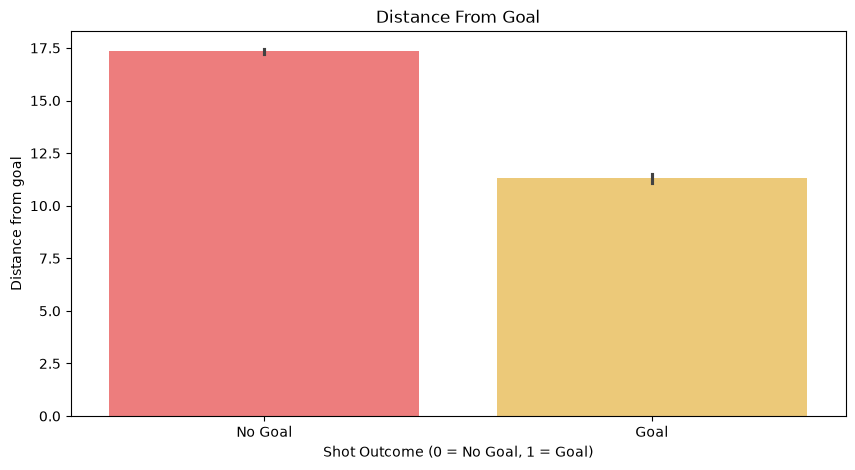

In [35]:
# How Distance from goal affect scoring
plt.figure(figsize=(10, 5))
sns.barplot(data=shot_df, x='ends_in_goal', y='dist_to_goal' , estimator='mean',hue='ends_in_goal' ,palette=['#FF6B6B', '#FFD166'],legend=False)
plt.xticks([0, 1], ['No Goal', 'Goal'])
plt.title('Distance From Goal')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Distance from goal')
plt.show()

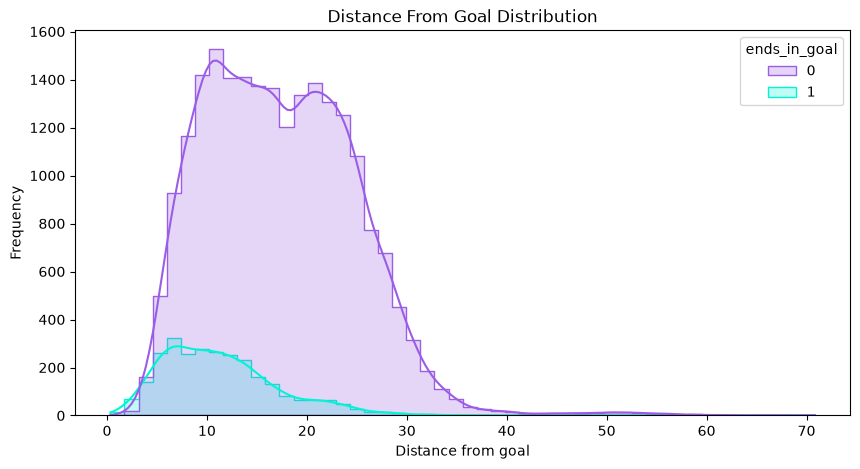

In [36]:
# Distance From Goal Distribution -> Diff by Goal or Not
plt.figure(figsize=(10, 5))
sns.histplot(data=shot_df, x='dist_to_goal', bins=50, kde=True,hue='ends_in_goal' , palette=['#9B5DE5', '#00F5D4'],element='step')
plt.title('Distance From Goal Distribution')
plt.xlabel('Distance from goal')
plt.ylabel('Frequency')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\1877579588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shot_df, x='ends_in_goal', y='shot_angle', palette=['#E07A5F', '#3D9970'])


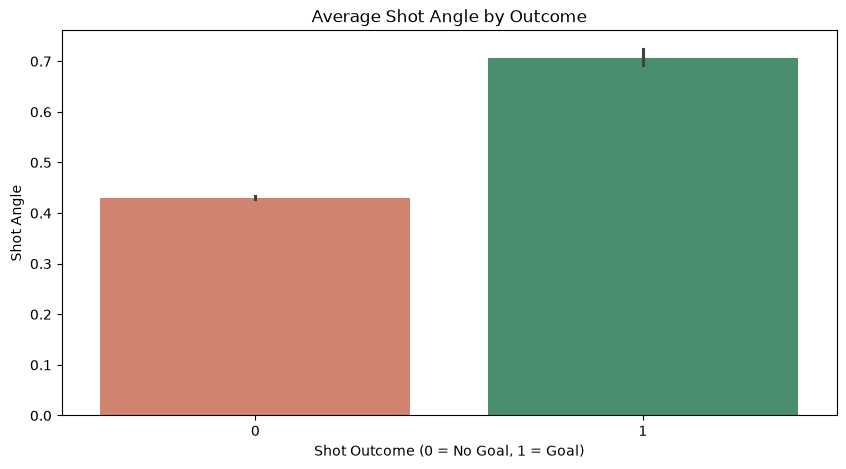

In [37]:
# How Shot Angle affects scoring
plt.figure(figsize=(10, 5))
sns.barplot(data=shot_df, x='ends_in_goal', y='shot_angle', palette=['#E07A5F', '#3D9970'])
plt.title('Average Shot Angle by Outcome')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Shot Angle')
plt.show()

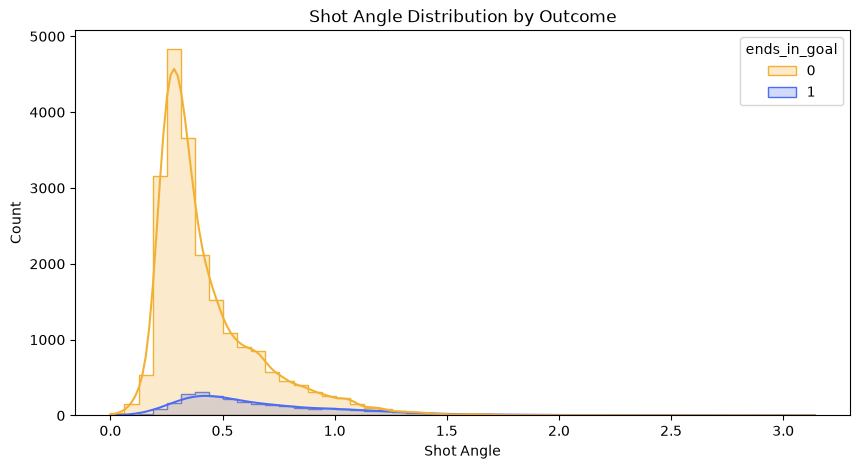

In [38]:
# Shot Angle Distribution -> Diff by Goal or Not
plt.figure(figsize=(10, 5))
sns.histplot(data=shot_df, x='shot_angle', hue='ends_in_goal', bins=50, kde=True,element='step', palette=['#F2B134', '#4C6EF5'])
plt.title('Shot Angle Distribution by Outcome')
plt.xlabel('Shot Angle')
plt.ylabel('Count')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\1111930186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shot_df, x='ends_in_goal', y='open_angle_goal', palette=['#B565A7', '#009B77'])


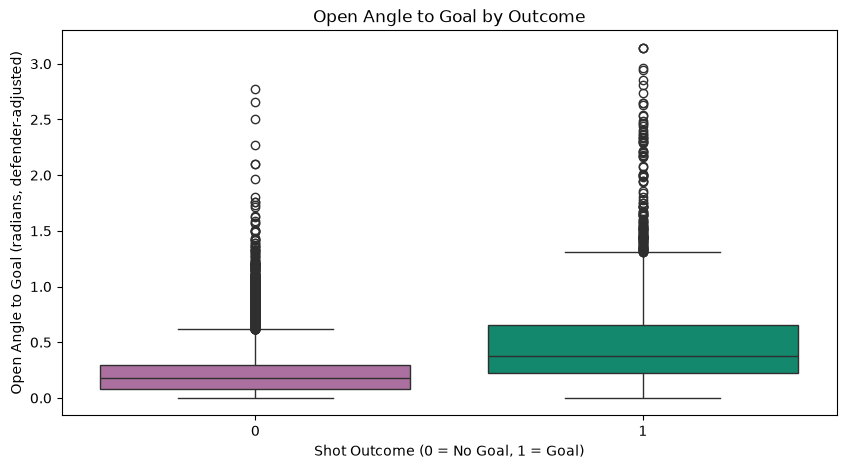

In [39]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=shot_df, x='ends_in_goal', y='open_angle_goal', palette=['#B565A7', '#009B77'])
plt.title('Open Angle to Goal by Outcome')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Open Angle to Goal (radians, defender-adjusted)')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\1138863019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shot_df, x='ends_in_goal', y='dist_nearest_defender', palette=['#DD4124', '#45B8AC'])


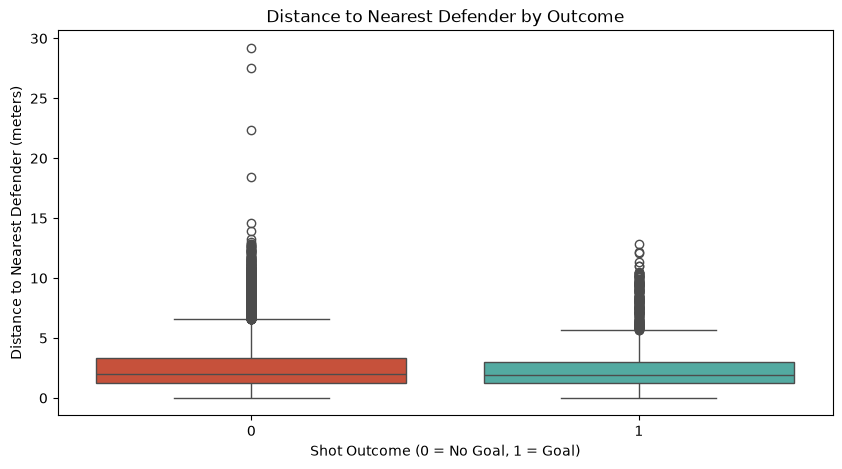

In [40]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=shot_df, x='ends_in_goal', y='dist_nearest_defender', palette=['#DD4124', '#45B8AC'])
plt.title('Distance to Nearest Defender by Outcome')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Distance to Nearest Defender (meters)')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\2037677118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shot_df, x='ends_in_goal', y='trajectory_length', palette=['#FF6F61', '#6B5B95'])


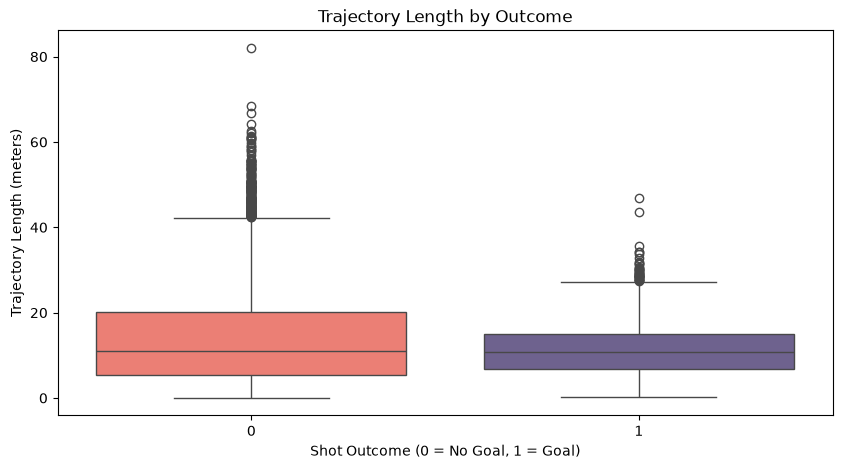

In [41]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=shot_df, x='ends_in_goal', y='trajectory_length', palette=['#FF6F61', '#6B5B95'])
plt.title('Trajectory Length by Outcome')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Trajectory Length (meters)')
plt.show()

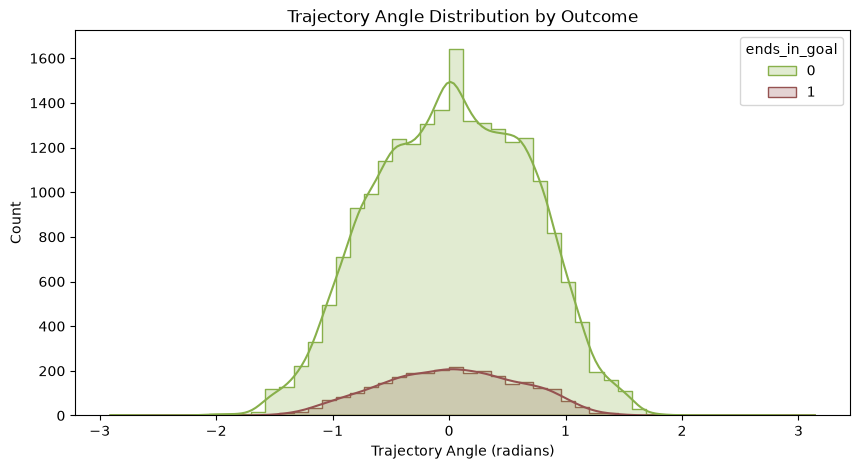

In [42]:
plt.figure(figsize=(10, 5))
sns.histplot(data=shot_df, x='trajectory_angle', hue='ends_in_goal', bins=50, kde=True,element='step', palette=['#88B04B', '#955251'])
plt.title('Trajectory Angle Distribution by Outcome')
plt.xlabel('Trajectory Angle (radians)')
plt.ylabel('Count')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\1595098704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shot_df, x='ends_in_goal', y='ball_speed', palette=['#F7CAC9', '#92A8D1'])


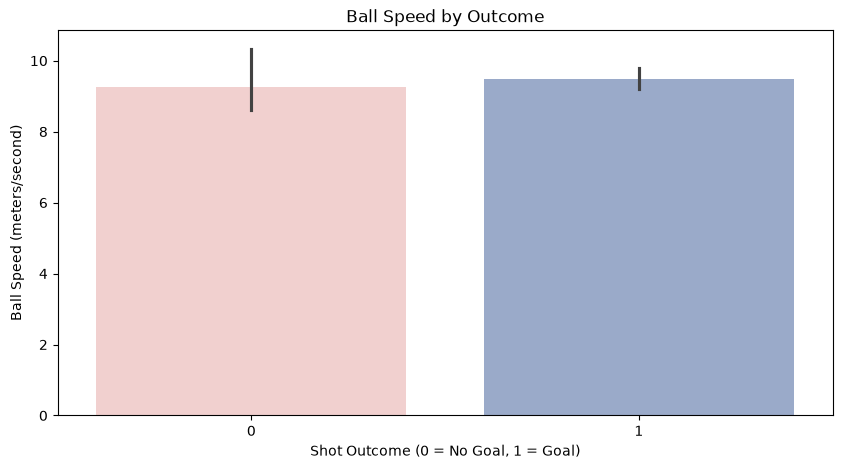

In [43]:
plt.figure(figsize=(10, 5))
sns.barplot(data=shot_df, x='ends_in_goal', y='ball_speed', palette=['#F7CAC9', '#92A8D1'])
plt.title('Ball Speed by Outcome')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Ball Speed (meters/second)')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\2781463503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shot_df, x='ends_in_goal', y='team_centroid_distance', palette=['#F49D6E', '#59A5D8'])


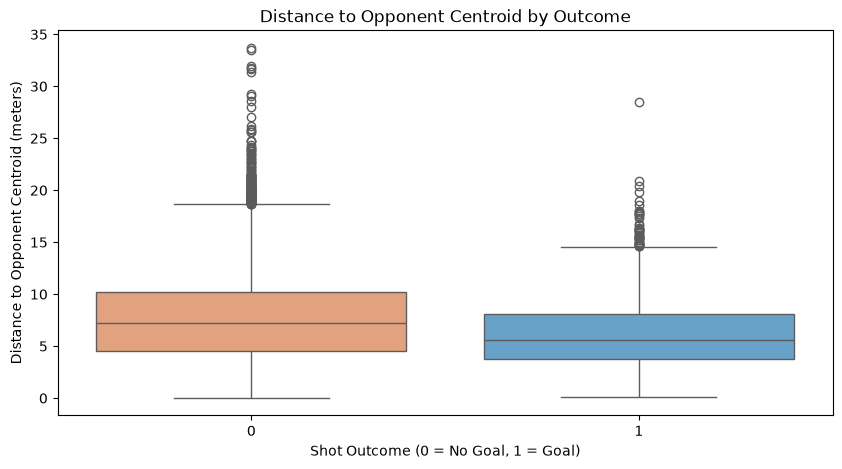

In [44]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=shot_df, x='ends_in_goal', y='team_centroid_distance', palette=['#F49D6E', '#59A5D8'])
plt.title('Distance to Opponent Centroid by Outcome')
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Distance to Opponent Centroid (meters)')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\2159456505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shot_df, x='defenders_in_3m', y='ends_in_goal',estimator='mean', palette='flare')


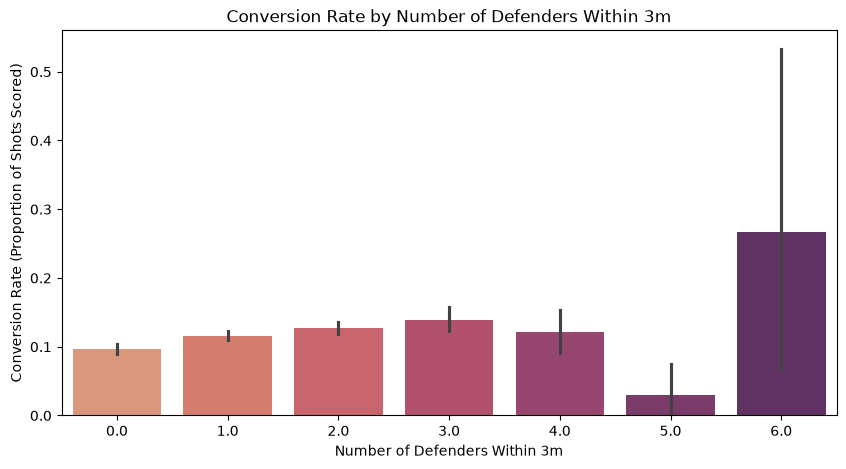

In [45]:
plt.figure(figsize=(10, 5))
sns.barplot(data=shot_df, x='defenders_in_3m', y='ends_in_goal',estimator='mean', palette='flare')
plt.title('Conversion Rate by Number of Defenders Within 3m')
plt.xlabel('Number of Defenders Within 3m')
plt.ylabel('Conversion Rate (Proportion of Shots Scored)')
plt.show()

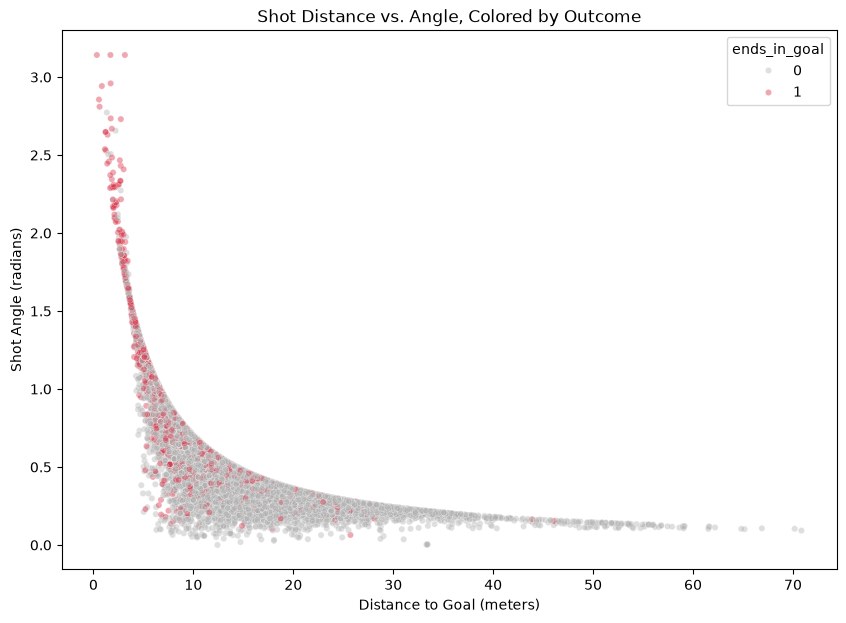

In [46]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=shot_df, x='dist_to_goal', y='shot_angle', hue='ends_in_goal',palette=['#B0B0B0', '#D7263D'], alpha=0.4, s=20)
plt.title('Shot Distance vs. Angle, Colored by Outcome')
plt.xlabel('Distance to Goal (meters)')
plt.ylabel('Shot Angle (radians)')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\1436731977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shot_df, x='in_penalty_box', y='ends_in_goal', palette=['#EFC050', '#5B5EA6'])


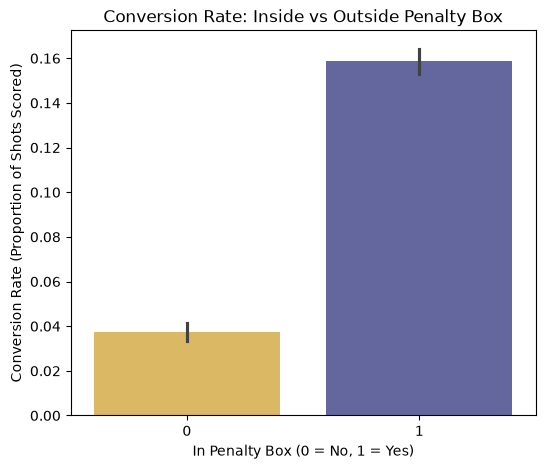

In [47]:
plt.figure(figsize=(6, 5))
sns.barplot(data=shot_df, x='in_penalty_box', y='ends_in_goal', palette=['#EFC050', '#5B5EA6'])
plt.title('Conversion Rate: Inside vs Outside Penalty Box')
plt.xlabel('In Penalty Box (0 = No, 1 = Yes)')
plt.ylabel('Conversion Rate (Proportion of Shots Scored)')
plt.show()

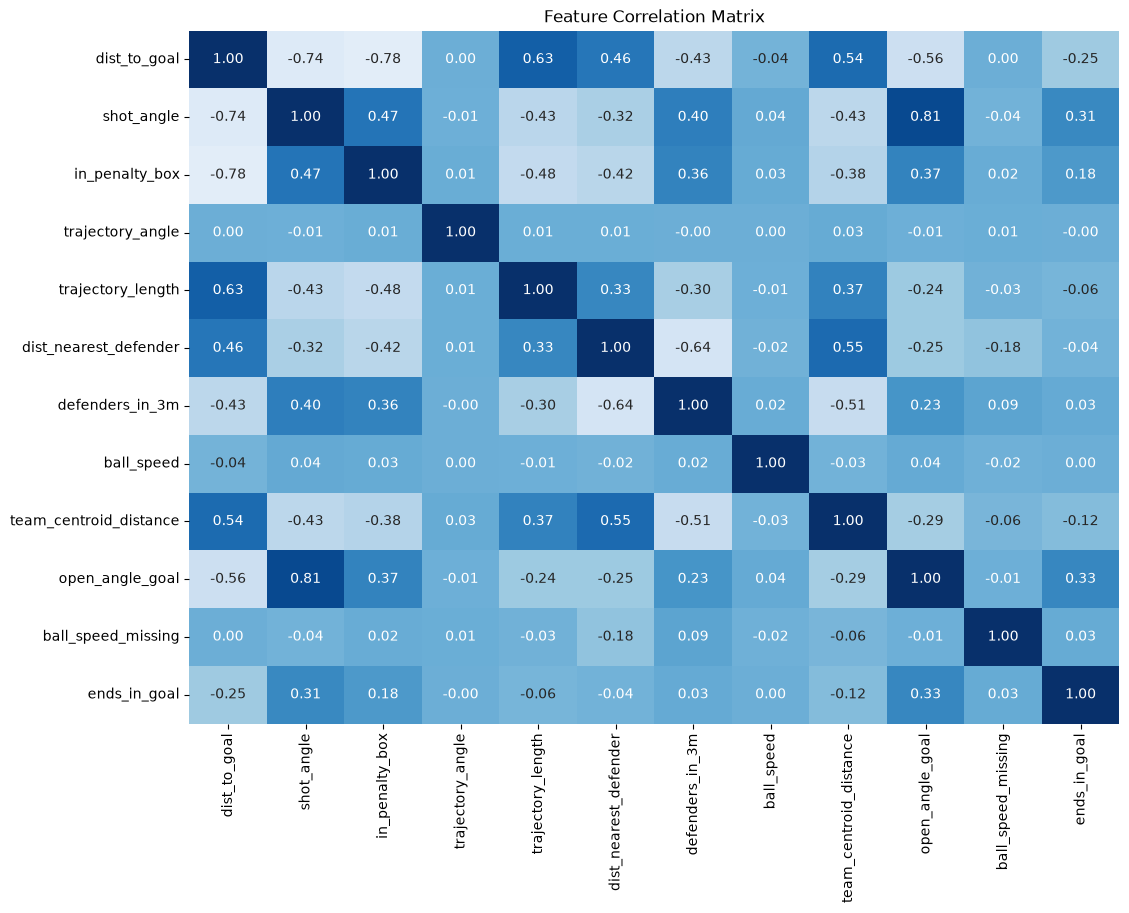

In [48]:
numeric_cols = ['dist_to_goal', 'shot_angle', 'in_penalty_box', 'trajectory_angle',
                 'trajectory_length', 'dist_nearest_defender', 'defenders_in_3m',
                 'ball_speed', 'team_centroid_distance', 'open_angle_goal',
                 'ball_speed_missing', 'ends_in_goal']

plt.figure(figsize=(12, 9))
sns.heatmap(shot_df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='Blues', center=0 , cbar=False)
plt.title('Feature Correlation Matrix')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27940\1814580024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=shot_df, x='ends_in_goal', palette=['#F76C6C', '#374785'])


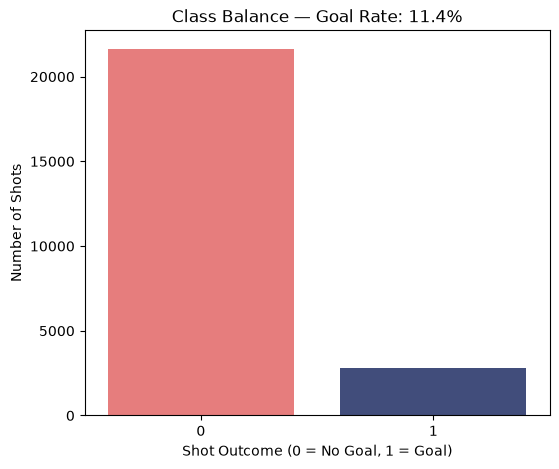

In [49]:
# Class Balance
plt.figure(figsize=(6, 5))
sns.countplot(data=shot_df, x='ends_in_goal', palette=['#F76C6C', '#374785'])
plt.title(f"Class Balance — Goal Rate: {shot_df['ends_in_goal'].mean()*100:.1f}%")
plt.xlabel('Shot Outcome (0 = No Goal, 1 = Goal)')
plt.ylabel('Number of Shots')
plt.show()